# **Nearest Neighbour (NN) comparison between 3D and its 2D projection as a function of N (number of points), and SDR (spatial dynamic range).**

- Generates N random points within a 3D sphere (radius R).
- Optionally rotates the cloud (Euler angles) before projection.
- Projects to 2D by dropping the z-axis.
- Removes points closer than smoothing length as defined by SDR (Spatial Dynamic Range).
- Computes NN in 3D and 2D.
- Compares edge sets and lengths; reports overlap metrics.
- Plots ratio of 3D to 2D NN lengths as a function of N, SDR, and Fractal dimension.
- Plots ratio of 3D to 2D NN lengths as function of N and SDR in a 3D surface, and fits a trend plane.
- Returns fitted parameters in form: $$C(N, SDR) = C_\infty * [1 - \exp(-SDR / S_0)] * (N / N_0)^\beta.$$

Fitting this form to the grid of ensemble-averaged measurements from 1000 fractal realisations with $D=1.7$-$2.5$, 
$n_{\mathrm{div}}=2$-$4$ yields:
\begin{align*}
\mathcal{C}_\infty &= 1.94 \pm 0.01,\\
S_0      &= 21.8 \pm 0.3,\\
\beta    &= 0.173 \pm 0.003.
\end{align*}

Produces the following from Barnes et al. (2026): 

- **Fig 6**: Nearest–neighbour projection ratio ℓ3D/ℓ2D versus sample size
N for fractal ensembles. For each N, we average 100 realisations
per configuration and then combine across nine fractal setups (D ∈
{1.7, 2.0, 2.5}, ndiv ∈ {2, 3, 4}) with jitter=True and prune=True.
The solid curve shows the cross-configuration mean, and the dashed
curves indicate ±1σ across configurations (not the run-to-run uncer-
tainty). The horizontal dashed line marks the geometric fixed-pair base-
line 4/π ≃ 1.27. Projection bias is present at all N, with ℓ3D/ℓ2D increas-
ing sub-linearly with N and reaching ∼ 2.0–2.3 by N = 200 depending
on fractal parameters. Higher D (less clumpy) yields larger ratios at
fixed N, indicating that beyond geometric compression, crowding and
neighbour reassignment drive additional shortening in projection.

- **Fig 7**: Nearest–neighbour projection ratio ⟨ℓ3D⟩/⟨ℓ2D⟩ as a function
of spatial dynamic range (SDR), evaluated for fractal ensembles (D =
1.7–2.5, ndiv = 2–4) at fixed N = 200. Points and shaded bands show
the mean and ±1σ scatter across configurations. The projection bias
increases rapidly up to SDR ∼ 10–20, beyond which it asymptotically
approaches the intrinsic structural limit (C∞ ≈ 1.9–2.0). At low SDR,
beam blending dominates, merging close pairs and driving C → 1, i.e.
apparent isometry between 3D and 2D separations.

- **Fig 8**: Combined dependence of the projection distortion ratio C(N, SDR) = ⟨ℓ3D⟩/⟨ℓ2D⟩ on sample size N and spatial dynamic range (SDR).
Left: ensemble-averaged measurements from 1000 fractal realisations with D = 1.7–2.5, and ndiv = 2–4; Middle: best-fitting three-parameter
model; Right: fractional residuals (Cmeas − Cfit)/Cfit. The fitted parameters (C∞ = 1.94, S 0 = 21.8, β = 0.17) capture
the joint behaviour across two orders of magnitude in both variables. The model converges to the geometric projection limit (C ≃ 1.3) for small,
well-resolved samples, and to the beam-limited regime (C ≃ 1) when SDR ≲ 10.

- **Table 1**: Fitted projection–correction factors C(N, SDR) from the empirical relation, using C∞ =
pirical relation, using C∞ =
1.94, S 0 = 21.8, and β = 0.173. The calibration is based on idealised,
complete simulations; when applied to real data with finite sensitivity,
blending, and Nobs < N, these values should be treated as approximate
corrections and, if evaluated with Nobs, as lower limits on the true 3D
spacing (see Sect. 5.3).

- **Fig. C.1**: Projection ratio C = ⟨ℓ3D⟩/⟨ℓ2D⟩ as a function of fractal di-
mension D for N = 200, evaluated at three spatial dynamic ranges:
SDR = 10 (blue), SDR = 50 (orange), and the effectively infinite–
resolution limit SDR → ∞ (green). Lower values of D correspond to
more strongly clustered, filamentary (more “fractal”) structures, while
higher values of D approach smoother, more space–filling morpholo-
gies. Solid lines show ensemble means, while shaded regions indicate
the 1σ scatter across Monte Carlo realisations. The projection ratio in-
creases monotonically with D and approaches an approximately asymp-
totic value at high D, with finite spatial resolution systematically reduc-
ing C at all fractal dimensions.

In [1]:
# Core scientific imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from scipy.stats import ks_2samp, skew, kurtosis

# corespaceing3d imports
from corespaceing3d import main
from corespaceing3d.plotting import rcParams

In [2]:
def summarize_profile_stats(name, len3_runs, len2_runs,
                            N_POINTS=None, RADIUS=None,
                            label=None, params=None):
    """
    Print simple + clever summary stats for one profile across many runs.

    Parameters
    ----------
    name : str
        Short profile key, e.g. 'uniform', 'gaussian'.
    len3_runs, len2_runs : list of 1D arrays
        Per-run NN edge-length arrays (3D and 2D).
    N_POINTS, RADIUS : optional
        If provided, printed for context.
    label : str, optional
        Nice printable label for the profile.
    params : dict, optional
        Profile parameters to print (e.g. {'sigma':0.25}).
    """
    # Concatenate all runs
    all3 = np.concatenate(len3_runs) if len3_runs else np.array([])
    all2 = np.concatenate(len2_runs) if len2_runs else np.array([])

    # Run-level means (NaN-safe)
    mu3 = np.array([np.mean(x) if len(x) else np.nan for x in len3_runs], dtype=float)
    mu2 = np.array([np.mean(x) if len(x) else np.nan for x in len2_runs], dtype=float)

    # Ratios per run (NaN-safe)
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_3D_over_2D = mu3 / mu2
        ratio_2D_over_3D = mu2 / mu3

    header = f"=== Profile: {name}"
    if label: header += f" — {label}"
    header += " ==="
    print(header)
    if params: print(f"Params: {params}")
    if N_POINTS is not None or RADIUS is not None:
        print(f"N_POINTS = {N_POINTS}, RADIUS = {RADIUS}")

    print(f"Total runs: {len(len3_runs)}")
    print(f"Total edges: 3D={all3.size}, 2D={all2.size}")

    # ---- Global (pooled) stats ----
    if all3.size:
        print(f"Global 3D mean edge length = {all3.mean():.4f} ± {all3.std(ddof=1):.4f}")
    if all2.size:
        print(f"Global 2D mean edge length = {all2.mean():.4f} ± {all2.std(ddof=1):.4f}")

    # ---- Run-level stats (variation across realizations) ----
    if np.isfinite(mu3).any():
        print(f"Run-level 3D mean = {np.nanmean(mu3):.4f} ± {np.nanstd(mu3, ddof=1):.4f}")
    if np.isfinite(mu2).any():
        print(f"Run-level 2D mean = {np.nanmean(mu2):.4f} ± {np.nanstd(mu2, ddof=1):.4f}")

    if np.isfinite(ratio_3D_over_2D).any():
        r = np.nanmean(ratio_3D_over_2D)
        s = np.nanstd(ratio_3D_over_2D, ddof=1)
        ci = np.nanpercentile(ratio_3D_over_2D, [16, 84])
        print(f"Run-level ratio (3D/2D) = {r:.3f} ± {s:.3f}  "
              f"[16–84%: {ci[0]:.3f}–{ci[1]:.3f}]")
    if np.isfinite(ratio_2D_over_3D).any():
        r = np.nanmean(ratio_2D_over_3D)
        s = np.nanstd(ratio_2D_over_3D, ddof=1)
        ci = np.nanpercentile(ratio_2D_over_3D, [16, 84])
        print(f"Run-level ratio (2D/3D) = {r:.3f} ± {s:.3f}  "
              f"[16–84%: {ci[0]:.3f}–{ci[1]:.3f}]")

    # ---- Medians & percentiles (pooled) ----
    if all3.size and all2.size:
        med3, med2 = np.median(all3), np.median(all2)
        print(f"Median edge lengths: 3D={med3:.4f}, 2D={med2:.4f}")
        for q in [5, 25, 50, 75, 95]:
            p3, p2 = np.percentile(all3, q), np.percentile(all2, q)
            print(f"Percentile {q:2d}: 3D={p3:.4f}, 2D={p2:.4f}")

    # ---- Distribution overlap diagnostic (range overlap) ----
    if all3.size and all2.size:
        lo_all = min(all3.min(), all2.min())
        hi_all = max(all3.max(), all2.max())
        lo_ov  = max(all3.min(), all2.min())
        hi_ov  = min(all3.max(), all2.max())
        ov_len = max(0.0, hi_ov - lo_ov)
        rng    = max(1e-12, hi_all - lo_all)
        overlap_fraction = ov_len / rng
        print(f"Distribution overlap range fraction = {overlap_fraction:.2f}")

        # KS test
        ks_stat, ks_p = ks_2samp(all3, all2)
        print(f"Kolmogorov–Smirnov test: D={ks_stat:.3f}, p={ks_p:.3e}")

        # Coefficient of variation, skewness, kurtosis
        cv3 = all3.std(ddof=1) / all3.mean()
        cv2 = all2.std(ddof=1) / all2.mean()
        print(f"Coefficient of variation: 3D={cv3:.3f}, 2D={cv2:.3f}")
        print(f"Skewness: 3D={skew(all3):.2f}, 2D={skew(all2):.2f}")
        print(f"Kurtosis (excess): 3D={kurtosis(all3):.2f}, 2D={kurtosis(all2):.2f}")

    print()

In [3]:
# ------------------------- configuration -------------------------
N_POINTS = 10      # number of points
RADIUS = 1.0         # sphere radius

# Rotation of the 3D clump *before* projecting to 2D
# (Right-handed, extrinsic rotations; order Z (alpha), Y (beta), X (gamma))
ALPHA_DEG = 0     # rotate about Z
BETA_DEG  = 0     # rotate about Y
GAMMA_DEG = 0     # rotate about X

# Toggle plotting
SHOW_PLOTS = True
# -----------------------------------------------------------------

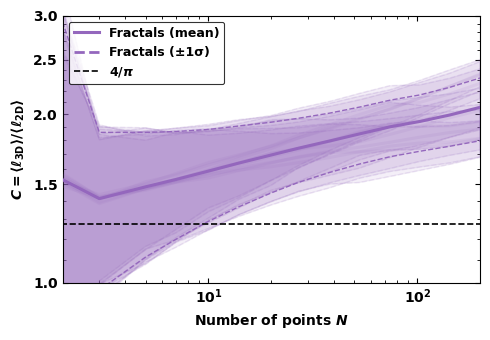

In [4]:
def plot_ratio_vs_N(
    N_values,
    runs=50,
    profile="uniform",
    profile_kwargs=None,
    RADIUS=1.0,
    ALPHA_DEG=0.0,
    BETA_DEG=0.0,
    GAMMA_DEG=0.0,
    BASE_SEED=0,
    show_points=True,
    ax=None,
    label=None,
    color="tab:purple",
    savepath=None,
    alpha=1.0,
):
    """
    For each N in N_values, run the pipeline 'runs' times and compute
    C = mean(len3) / mean(len2). Plot the mean C(N) and ±1σ band.

    Parameters
    ----------
    N_values : array-like
        List/array of N (number of points) to test.
    runs : int
        Number of realizations per N.
    profile : str
        'uniform' | 'gaussian' | 'powerlaw' | 'plummer' | 'exponential' | 'shell'
    profile_kwargs : dict or None
        Parameters for the chosen profile (e.g. {'sigma':0.25}, {'p':-2}, {'a':0.25}).
    RADIUS, ALPHA_DEG, BETA_DEG, GAMMA_DEG : float
        Geometry settings passed to main().
    BASE_SEED : int
        Base seed; per-run seeds are BASE_SEED + k.
    show_points : bool
        If True, plot faint per-run ratios as scatter.
    ax : matplotlib.axes.Axes or None
        Axis to draw on. If None, a new fig/ax is created.
    label : str or None
        Label for the mean curve (useful if overlaying multiple profiles).
    color : str
        Matplotlib color for the mean line and band.
    savepath : str or None
        If given, save the figure to this path.

    Returns
    -------
    result : dict
        {
          'N_values': np.ndarray,
          'ratios': list of np.ndarray (per-run ratios for each N),
          'mean': np.ndarray,
          'std': np.ndarray
        }
    """
    if profile_kwargs is None:
        profile_kwargs = {}

    N_values = np.asarray(N_values, dtype=int)
    ratios_per_N = []
    means = []
    stds = []

    for i, N in enumerate(N_values):
        r_list = []
        for k in range(runs):
            out = main(
                N_POINTS=N,
                RADIUS=RADIUS,
                SEED=BASE_SEED + k,
                profile=profile,
                profile_kwargs=profile_kwargs,
                ALPHA_DEG=ALPHA_DEG,
                BETA_DEG=BETA_DEG,
                GAMMA_DEG=GAMMA_DEG,
                verbose=False,
            )

            len3 = np.asarray(out["len3"], dtype=float)
            len2 = np.asarray(out["len2"], dtype=float)
            # Per-run ratio: mean 3D edge length divided by mean 2D edge length
            m3 = len3.mean() if len3.size else np.nan
            m2 = len2.mean() if len2.size else np.nan
            r = m3 / m2 if (np.isfinite(m3) and np.isfinite(m2) and m2 > 0) else np.nan
            r_list.append(r)

        r_arr = np.array(r_list, dtype=float)
        ratios_per_N.append(r_arr)
        means.append(np.nanmean(r_arr))
        stds.append(np.nanstd(r_arr, ddof=1))

    means = np.array(means, dtype=float)
    stds = np.array(stds, dtype=float)

    # ---- Plot ----
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6.5, 4.0))
        created_fig = True

    # Optional scatter of all per-run points (faint)
    if show_points:
        for N, r_arr in zip(N_values, ratios_per_N):
            x = np.full_like(r_arr, N, dtype=float)
            ax.scatter(x, r_arr, s=10, alpha=0.15, color=color, zorder=1)

    # Mean curve and ±1σ band
    lbl = label if label else f"{profile}"
    # Compose a pretty label with params
    if label is None and profile_kwargs:
        if profile == "gaussian" and "sigma" in profile_kwargs:
            lbl += rf" ($\sigma={profile_kwargs['sigma']}$)"
        elif profile == "powerlaw" and "p" in profile_kwargs:
            lbl += rf" ($p={profile_kwargs['p']}$)"
        elif profile == "plummer" and "a" in profile_kwargs:
            lbl += rf" ($a={profile_kwargs['a']}$)"
        elif profile == "exponential" and "r0" in profile_kwargs:
            lbl += rf" ($r_0={profile_kwargs['r0']}$)"
        elif profile == "shell" and "r0" in profile_kwargs:
            lbl += rf" ($r_0={profile_kwargs['r0']}$)"
        elif profile == "fractal" and "D" in profile_kwargs:
            lbl += rf" ($D={profile_kwargs['D']}$, n$_\mathrm{{div}}$={profile_kwargs.get('n_div',2)})"

    ax.plot(N_values, means, color=color, lw=2.2, label=lbl, zorder=3, alpha=alpha)
    ax.fill_between(N_values, means - stds, means + stds, color=color, alpha=0.1, zorder=2)
    ax.plot(N_values, means - stds, color=color, lw=1.0, ls='--', zorder=2, alpha=alpha)
    ax.plot(N_values, means + stds, color=color, lw=1.0, ls='--', zorder=2, alpha=alpha)

    ax.set_xlabel("Number of points $N$")
    # ax.set_ylabel(r"$\,\overline{\ell}_{\rm 3D}/\overline{\ell}_{\rm 2D}\,$")
    ax.set_ylabel(r"$C= \langle \ell_{\rm 3D} \rangle/ \langle \ell_{\rm 2D} \rangle$")
    # ax.grid(True, alpha=0.3)
    # ax.legend(frameon=True, fontsize=9)

    # Reasonable limits: start at 0 on y, a little headroom on top
    ymin = max(0.0, np.nanmin(means - stds))
    ymax = np.nanmax(means + stds)
    ax.set_ylim(0.0, 1.1 * ymax if np.isfinite(ymax) else 1.0)

    # If N spans a big range, you may want log-x:
    # ax.set_xscale("log"); ax.set_xticks(N_values); ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())

    if created_fig:
        plt.tight_layout()
        if savepath:
            plt.savefig(savepath, dpi=300, bbox_inches="tight")

    return {
        "N_values": N_values,
        "ratios": ratios_per_N,
        "mean": means,
        "std": stds,
    }

jitter = True  # add small Gaussian jitter to break grid regularity
prune = True   # prune to sphere before scaling (approx. spherical cluster)

N_values = np.logspace(np.log10(2), np.log10(200), num=15, dtype=int)
runs = 1000

fig, ax = plt.subplots(1, 1, figsize=(5, 3.5))
# out_uniform = plot_ratio_vs_N(N_values, runs=runs, profile="uniform",  color="grey",  ax=ax, show_points=False, alpha=0.3)

out_fractals = []

Ds = [1.7, 2.0, 2.5]
n_divs = [2, 3, 4]
for D in Ds:
    for n_div in n_divs:
        profile_kwargs = {'D':D, 'n_div':n_div, 'jitter':jitter, 'prune':prune}
        out_fractal = plot_ratio_vs_N(N_values, runs=runs, profile="fractal", profile_kwargs=profile_kwargs, color="C4",  ax=ax, show_points=False, alpha=0.1)
        out_fractals += [out_fractal]

# --- Compute ensemble mean and std across all (D, n_div) sets ---
means_stack = np.stack([of['mean'] for of in out_fractals])
stds_stack  = np.stack([of['std']  for of in out_fractals])

# Mean curve (ensemble average)
mean_fractal = np.nanmean(means_stack, axis=0)

# Total spread: combine scatter across (D, n_div) mean curves and their internal stds
spread_between = np.nanstd(means_stack, axis=0, ddof=1)   # variation of means
spread_within  = np.nanmean(stds_stack, axis=0)           # average internal std
std_fractal = np.sqrt(spread_between**2 + spread_within**2)

# --- Plot mean ±σ band ---
ax.plot(N_values, mean_fractal, color="C4", lw=2.2, label="Fractals", zorder=3, alpha=1.0)
ax.plot(N_values, mean_fractal - std_fractal, color="C4", lw=1.0, ls='--', zorder=2, alpha=1.0)
ax.plot(N_values, mean_fractal + std_fractal, color="C4", lw=1.0, ls='--', zorder=2, alpha=1.0)

ax.set_xlim(N_values[0], N_values[-1])
ax.set_ylim(1, 3)
ax.set_xscale("log")
ax.set_yscale("log")

# Choose desired tick positions manually (linear-style numbers)
yticks = [1.0, 1.5, 2.0, 2.5, 3]
ax.set_yticks(yticks)
ax.set_yticklabels([f"{t:.1f}" for t in yticks])

# Minor ticks: linearly spaced every 0.1
minor_ticks = np.arange(1.0, 3.0 + 0.1, 0.1)
ax.yaxis.set_minor_locator(mticker.FixedLocator(minor_ticks))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())  # hide minor tick labels

ax.plot([0,500], [4/np.pi]*2, 'k--', lw=1.2, label=r"$4/\pi$")

# --- custom legend (proxy artists) ---
leg_mean  = Line2D([], [], color="C4", lw=2.2, label="Fractals (mean)")
leg_pm1   = Line2D([], [], color="C4", lw=2, ls="--", label="Fractals (±1σ)")
leg_geom  = Line2D([], [], color="k",  lw=1.2, ls="--", label=r"$4/\pi$")

leg = ax.legend(handles=[leg_mean, leg_pm1, leg_geom],
                loc="upper left", frameon=True, fontsize=9)

# optional: tweak the legend frame
leg.get_frame().set_facecolor("white")
leg.get_frame().set_edgecolor("black")
leg.get_frame().set_linewidth(0.8)

fig.tight_layout()
fig.savefig("./../figures/ratio_vs_N_all_fractal_profiles.pdf", dpi=300, bbox_inches="tight")

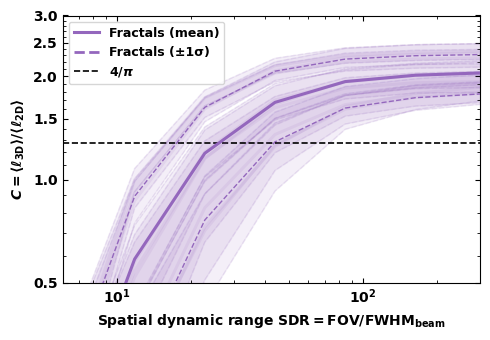

In [5]:
def plot_ratio_vs_dynrange(
    dyn_values,
    N_POINTS=200,
    runs=50,
    profile="uniform",
    profile_kwargs=None,
    RADIUS=1.0,
    ALPHA_DEG=0.0,
    BETA_DEG=0.0,
    GAMMA_DEG=0.0,
    BASE_SEED=0,
    show_points=True,
    ax=None,
    label=None,
    color="tab:purple",
    savepath=None,
    alpha=1.0,
):
    """
    For a fixed N_POINTS, vary the spatial dynamic range (SDR)
    and compute C = <ell_3D>/<ell_2D>.
    Correctly merges user-supplied profile_kwargs (e.g. fractal params)
    with dyn_range for beam blending.
    """
    if profile_kwargs is None:
        profile_kwargs = {}

    dyn_values = np.asarray(dyn_values, dtype=float)
    ratios_per_dyn = []
    means, stds = [], []

    for i, dyn in enumerate(dyn_values):
        r_list = []
        for k in range(runs):
            # --- merge fractal params + dyn_range ---
            pk = dict(profile_kwargs)
            pk["dyn_range"] = dyn

            out = main(
                N_POINTS=N_POINTS,
                RADIUS=RADIUS,
                SEED=BASE_SEED + i * 1000 + k,  # offset by SDR and run index
                profile=profile,
                profile_kwargs=pk,
                ALPHA_DEG=ALPHA_DEG,
                BETA_DEG=BETA_DEG,
                GAMMA_DEG=GAMMA_DEG,
                verbose=False,
            )

            len3 = np.asarray(out["len3"], dtype=float)
            len2 = np.asarray(out["len2"], dtype=float)
            m3 = len3.mean() if len3.size else np.nan
            m2 = len2.mean() if len2.size else np.nan
            r = m3 / m2 if (np.isfinite(m3) and np.isfinite(m2) and m2 > 0) else np.nan
            r_list.append(r)

        r_arr = np.array(r_list, dtype=float)
        ratios_per_dyn.append(r_arr)
        means.append(np.nanmean(r_arr))
        stds.append(np.nanstd(r_arr, ddof=1))

    means, stds = np.array(means), np.array(stds)

    # --- Plot ---
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6, 4))
        created_fig = True

    if show_points:
        for dyn, r_arr in zip(dyn_values, ratios_per_dyn):
            ax.scatter(np.full_like(r_arr, dyn, dtype=float), r_arr,
                       s=10, alpha=0.15, color=color, zorder=1)

    lbl = label or f"{profile}"
    ax.plot(dyn_values, means, color=color, lw=2.2, label=lbl, zorder=3, alpha=alpha)
    ax.fill_between(dyn_values, means - stds, means + stds, color=color, alpha=0.1)
    ax.plot(dyn_values, means - stds, color=color, lw=1.0, ls='--', alpha=alpha)
    ax.plot(dyn_values, means + stds, color=color, lw=1.0, ls='--', alpha=alpha)

    # ax.set_xscale("log")
    ax.set_xlabel(r"Spatial dynamic range $\mathrm{SDR} = \mathrm{FOV}/\mathrm{FWHM}_{\rm beam}$")
    ax.set_ylabel(r"$\langle \ell_{\rm 3D} \rangle / \langle \ell_{\rm 2D} \rangle$")
    # ax.grid(True, alpha=0.3)

    ymin = max(0.0, np.nanmin(means - stds))
    ymax = np.nanmax(means + stds)
    ax.set_ylim(0.0, 1.1 * ymax)

    if created_fig:
        plt.tight_layout()
        if savepath:
            plt.savefig(savepath, dpi=300, bbox_inches="tight")

    return {"dyn_values": dyn_values, "ratios": ratios_per_dyn, "mean": means, "std": stds}


# --- Define parameter grids ---
Ds = [1.7, 2.0, 2.5]
n_divs = [2, 3, 4]

runs = 1000
N_POINTS = 200

dyn_values = np.logspace(0.5, 2.5, 8)  # SDR = 3 → 300
out_fractals = []

fig, ax = plt.subplots(1, 1, figsize=(5, 3.5))

# --- Loop over all fractal parameter combinations ---
for D in Ds:
    for n_div in n_divs:
        profile_kwargs = {'D': D, 'n_div': n_div, 'jitter': True, 'prune': True}
        out_fractal = plot_ratio_vs_dynrange(
            dyn_values=dyn_values,
            N_POINTS=N_POINTS,
            runs=runs,
            profile="fractal",
            profile_kwargs=profile_kwargs,
            RADIUS=1.0,
            BASE_SEED=0,
            color="C4",
            ax=ax,
            show_points=False,
            alpha=0.1,
        )
        out_fractals.append(out_fractal)

# --- Compute ensemble mean and std across all (D, n_div) sets ---
means_stack = np.stack([of['mean'] for of in out_fractals])
stds_stack  = np.stack([of['std']  for of in out_fractals])

# Mean curve (ensemble average)
mean_fractal = np.nanmean(means_stack, axis=0)

# Total spread: combine scatter across (D, n_div) mean curves and their internal stds
spread_between = np.nanstd(means_stack, axis=0, ddof=1)   # variation of means
spread_within  = np.nanmean(stds_stack, axis=0)           # average internal std
std_fractal = np.sqrt(spread_between**2 + spread_within**2)

# --- Plot mean ±σ band ---
ax.plot(dyn_values, mean_fractal, color="C4", lw=2.2, label="Fractals (mean)", zorder=3)
ax.plot(dyn_values, mean_fractal - std_fractal, color="C4", lw=1.0, ls="--", alpha=1.0)
ax.plot(dyn_values, mean_fractal + std_fractal, color="C4", lw=1.0, ls="--", alpha=1.0)

# --- Reference geometric factor ---
ax.axhline(4 / np.pi, color="k", lw=1.2, ls="--", label=r"$4/\pi$")

# --- Axis labels and limits ---
ax.set_xscale("log")
ax.set_xlim(dyn_values[0], dyn_values[-1])
ax.set_ylim(0.5, 3)
ax.set_xlabel(r"Spatial dynamic range $\mathrm{SDR} = \mathrm{FOV}/\mathrm{FWHM}_{\rm beam}$")
ax.set_ylabel(r"$C=\langle \ell_{\rm 3D}\rangle / \langle \ell_{\rm 2D}\rangle$")
# ax.grid(True, alpha=0.3)

ax.set_xlim(6, 300)
ax.set_yscale("log")

# Choose desired tick positions manually (linear-style numbers)
yticks = [0.5, 1.0, 1.5, 2.0, 2.5, 3]
ax.set_yticks(yticks)
ax.set_yticklabels([f"{t:.1f}" for t in yticks])

# Minor ticks: linearly spaced every 0.1
minor_ticks = np.arange(0.5, 3.0 + 0.1, 0.1)
ax.yaxis.set_minor_locator(mticker.FixedLocator(minor_ticks))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())  # hide minor tick labels

# --- Legend and formatting ---
leg_mean = Line2D([], [], color="C4", lw=2.2, label="Fractals (mean)")
leg_pm1  = Line2D([], [], color="C4", lw=2.0, ls="--", label="Fractals (±1σ)")
leg_geom = Line2D([], [], color="k",  lw=1.2, ls="--", label=r"$4/\pi$")
ax.legend(handles=[leg_mean, leg_pm1, leg_geom], loc="upper left", fontsize=9, frameon=True)

fig.tight_layout()
fig.savefig("./../figures/ratio_vs_dynrange_fractals.pdf", dpi=300, bbox_inches="tight")

SDR=10: C ranges from 0.65 to 2.02 over D=1.5–2.8
SDR=50: C ranges from 1.42 to 2.38 over D=1.5–2.8
SDR=10000: C ranges from 1.73 to 2.43 over D=1.5–2.8


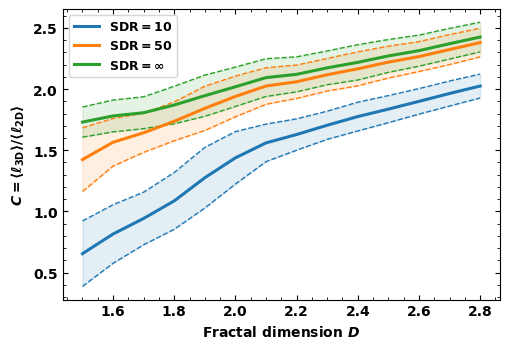

In [6]:
def compute_ratio_vs_D(
    D_values,
    dyn_range,
    N_POINTS=200,
    runs=200,
    n_div=3,
    profile="fractal",
    profile_kwargs=None,
    RADIUS=1.0,
    ALPHA_DEG=0.0,
    BETA_DEG=0.0,
    GAMMA_DEG=0.0,
    BASE_SEED=0,
):
    """
    For fixed N_POINTS and fixed spatial dynamic range (SDR = dyn_range),
    vary fractal dimension D and compute C = <ell_3D>/<ell_2D>.

    Assumes you have a function `main(...)` that returns a dict with keys:
      - "len3": array-like of 3D NN lengths
      - "len2": array-like of 2D NN lengths

    Parameters
    ----------
    D_values : array-like
        Fractal dimensions to evaluate.
    dyn_range : float
        Spatial dynamic range SDR = FOV / FWHM_beam.
    N_POINTS : int
        Number of points in each realisation.
    runs : int
        Number of Monte Carlo realisations per D.
    n_div : int
        Fractal subdivision level.
    profile : str
        Profile passed to `main`; should be "fractal".
    profile_kwargs : dict
        Extra kwargs for fractal generation (e.g. jitter/prune), merged with D, n_div, dyn_range.
    RADIUS : float
        Cluster radius.
    ALPHA_DEG, BETA_DEG, GAMMA_DEG : float
        Euler rotation angles in degrees.
    BASE_SEED : int
        Base RNG seed.

    Returns
    -------
    dict with keys: D_values, ratios, mean, std
    """
    if profile_kwargs is None:
        profile_kwargs = {}

    D_values = np.asarray(D_values, dtype=float)
    ratios_per_D = []
    means, stds = [], []

    for i, D in enumerate(D_values):
        r_list = []
        for k in range(runs):
            pk = dict(profile_kwargs)
            pk.update({"D": float(D), "n_div": int(n_div), "dyn_range": float(dyn_range)})

            out = main(
                N_POINTS=N_POINTS,
                RADIUS=RADIUS,
                SEED=BASE_SEED + i * 100000 + k,
                profile=profile,
                profile_kwargs=pk,
                ALPHA_DEG=ALPHA_DEG,
                BETA_DEG=BETA_DEG,
                GAMMA_DEG=GAMMA_DEG,
                verbose=False,
            )

            len3 = np.asarray(out["len3"], dtype=float)
            len2 = np.asarray(out["len2"], dtype=float)

            m3 = len3.mean() if len3.size else np.nan
            m2 = len2.mean() if len2.size else np.nan
            r = m3 / m2 if (np.isfinite(m3) and np.isfinite(m2) and m2 > 0) else np.nan
            r_list.append(r)

        r_arr = np.array(r_list, dtype=float)
        ratios_per_D.append(r_arr)
        means.append(np.nanmean(r_arr))
        stds.append(np.nanstd(r_arr, ddof=1))

    return {
        "D_values": D_values,
        "ratios": ratios_per_D,
        "mean": np.array(means),
        "std": np.array(stds),
    }


def plot_ratio_vs_D(
    D_values,
    dyn_range,
    N_POINTS=200,
    runs=200,
    n_div=3,
    profile_kwargs=None,
    ax=None,
    show_points=False,
    color="C0",
    label=None,
    alpha=1.0,
):
    """
    Convenience wrapper: compute_ratio_vs_D + plot mean ± std.
    """
    out = compute_ratio_vs_D(
        D_values=D_values,
        dyn_range=dyn_range,
        N_POINTS=N_POINTS,
        runs=runs,
        n_div=n_div,
        profile="fractal",
        profile_kwargs=profile_kwargs,
        RADIUS=1.0,
        BASE_SEED=0,
    )

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5.2, 3.6))
        created_fig = True

    if show_points:
        for D, r_arr in zip(out["D_values"], out["ratios"]):
            ax.scatter(np.full_like(r_arr, D, dtype=float), r_arr, s=10, alpha=0.15, color=color, zorder=1)

    lbl = label or rf"$\mathrm{{SDR}}={dyn_range}$"
    ax.plot(out["D_values"], out["mean"], color=color, lw=2.2, label=lbl, zorder=3, alpha=alpha)
    ax.fill_between(out["D_values"], out["mean"] - out["std"], out["mean"] + out["std"], color=color, alpha=0.12)
    ax.plot(out["D_values"], out["mean"] - out["std"], color=color, lw=1.0, ls="--", alpha=alpha)
    ax.plot(out["D_values"], out["mean"] + out["std"], color=color, lw=1.0, ls="--", alpha=alpha)

    ax.set_xlabel(r"Fractal dimension $D$")
    ax.set_ylabel(r"$C=\langle \ell_{\rm 3D}\rangle / \langle \ell_{\rm 2D}\rangle$")
    # ax.grid(True, alpha=0.3)

    if created_fig:
        plt.tight_layout()

    return out, ax


# =========================
# Example usage
# =========================
if __name__ == "__main__":
    # Representative settings
    N_POINTS = 200
    runs = 1000                  # increase if you want smaller error bars
    n_div = 3                   # pick one, or loop over [2,3,4] and average
    D_values = np.arange(1.5, 2.9, 0.1)  # 1.5 → 2.8

    profile_kwargs = {"jitter": True, "prune": True}

    fig, ax = plt.subplots(1, 1, figsize=(5.2, 3.6))

    # Two representative SDRs
    out30, ax = plot_ratio_vs_D(
        D_values=D_values,
        dyn_range=30,
        N_POINTS=N_POINTS,
        runs=runs,
        n_div=n_div,
        profile_kwargs=profile_kwargs,
        ax=ax,
        color="C0",
        label=r"$\mathrm{SDR}=10$",
    )
    out100, ax = plot_ratio_vs_D(
        D_values=D_values,
        dyn_range=100,
        N_POINTS=N_POINTS,
        runs=runs,
        n_div=n_div,
        profile_kwargs=profile_kwargs,
        ax=ax,
        color="C1",
        label=r"$\mathrm{SDR}=50$",
    )

    out1000, ax = plot_ratio_vs_D(
        D_values=D_values,
        dyn_range=10000,
        N_POINTS=N_POINTS,
        runs=runs,
        n_div=n_div,
        profile_kwargs=profile_kwargs,
        ax=ax,
        color="C2",
        label=r"$\mathrm{SDR}=\infty$",
    )

    ax.legend(loc="best", frameon=True, fontsize=9)
    fig.tight_layout()
    fig.savefig("./../figures/ratio_vs_D_fractals.pdf", dpi=300, bbox_inches="tight")

    # If you want a quick text summary for the manuscript:
    for dyn, out in [(10, out30), (50, out100), (10000, out1000)]:
        mean = out["mean"]
        Dv = out["D_values"]
        i_max = np.nanargmax(Dv)
        print(f"SDR={dyn}: C ranges from {np.nanmin(mean):.2f} to {np.nanmax(mean):.2f} over D={Dv[0]:.1f}–{Dv[-1]:.1f}")

In [7]:
# --------------------------------------------------------
# CONFIGURATION
# --------------------------------------------------------
Ds = [1.7, 2.0, 2.5]
n_divs = [2, 3, 4]
N_values = np.array([5, 8, 12, 18, 25, 35, 50, 70, 100, 140, 200], dtype=int)
dyn_values = np.array([5, 8, 12, 18, 25, 35, 50, 70, 100], dtype=float)
runs = 100
RADIUS = 1.0

# --------------------------------------------------------
# STORAGE
# --------------------------------------------------------
results = {}

# --------------------------------------------------------
# COMPUTE C(N, SDR) for each (D, n_div)
# --------------------------------------------------------
for D in Ds:
    for n_div in n_divs:
        key = f"D{D:.1f}_ndiv{n_div}"
        print(f"Running {key} ...")

        ratio_grid     = np.full((len(N_values), len(dyn_values)), np.nan)
        ratio_std_grid = np.full_like(ratio_grid, np.nan)  # NEW: run-to-run scatter

        for iN, N in enumerate(N_values):
            for jD, dyn_range in enumerate(dyn_values):

                r_list = []
                for k in range(runs):
                    profile_kwargs = {
                        "D": D, "n_div": n_div,
                        "jitter": True, "prune": True,
                        "dyn_range": dyn_range
                    }
                    out = main(
                        N_POINTS=N,
                        RADIUS=RADIUS,
                        SEED=1000 * iN + jD + k,
                        profile="fractal",
                        profile_kwargs=profile_kwargs,
                        ALPHA_DEG=0.0,
                        BETA_DEG=0.0,
                        GAMMA_DEG=0.0,
                        verbose=False,
                    )
                    len3 = np.asarray(out["len3"], dtype=float)
                    len2 = np.asarray(out["len2"], dtype=float)
                    m3 = np.nanmean(len3)
                    m2 = np.nanmean(len2)
                    if np.isfinite(m3) and np.isfinite(m2) and m2 > 0:
                        r_list.append(m3 / m2)

                if r_list:
                    r_arr = np.array(r_list, dtype=float)
                    ratio_grid[iN, jD]     = np.nanmean(r_arr)
                    ratio_std_grid[iN, jD] = np.nanstd(r_arr, ddof=1)

        results[key] = dict(
            N_values   = N_values,
            dyn_values = dyn_values,
            ratio      = ratio_grid,      # mean over runs
            ratio_std  = ratio_std_grid,  # run-to-run scatter
        )

Running D1.7_ndiv2 ...


/var/folders/3y/cmsgt3_x7x72bbs__zhy_q6h0008wr/T/ipykernel_57341/2222552367.py:51: RuntimeWarning: Mean of empty slice
  m2 = np.nanmean(len2)


Running D1.7_ndiv3 ...
Running D1.7_ndiv4 ...
Running D2.0_ndiv2 ...
Running D2.0_ndiv3 ...
Running D2.0_ndiv4 ...
Running D2.5_ndiv2 ...
Running D2.5_ndiv3 ...
Running D2.5_ndiv4 ...


Fit results:
  C_inf = 1.939 ± 0.012
  S0    = 21.82 ± 0.33
  beta  = 0.173 ± 0.003


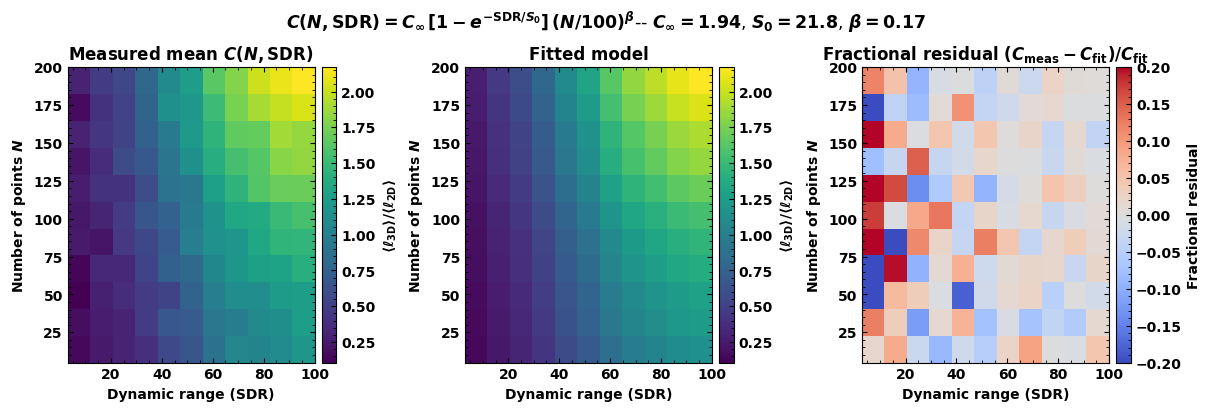

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Model: fit C_inf, S0, beta; keep N0 fixed (stable, fewer degeneracies) ---
def C_plaw(XY, C_inf, S0, beta, N0=100.0):
    """
    C(N, SDR) = C_inf * [1 - exp(-SDR / S0)] * (N / N0)**beta
    """
    N, SDR = XY
    N   = np.asarray(N, dtype=float)
    SDR = np.asarray(SDR, dtype=float)
    return C_inf * (1.0 - np.exp(-SDR / S0)) * (N / N0)**beta

# --- Build meshes (use your actual N_values, dyn_values and R_meas if you have them) ---
# Example grids; replace with your existing arrays
N_values  = np.array([5, 8, 10, 15, 20, 30, 50, 80, 100, 150, 200], dtype=float)
dyn_values = np.array([3, 5, 7, 10, 15, 20, 30, 40, 50, 70, 100], dtype=float)

Nmesh, SDRmesh = np.meshgrid(N_values, dyn_values, indexing='ij')

# If you already have measured R(N, SDR), set R_meas = your_data here.
# For demonstration we synthesize something plausible:
C_true = C_plaw((Nmesh, SDRmesh), C_inf=1.95, S0=22.0, beta=1/6)
rng = np.random.default_rng(7)
C_meas = C_true + rng.normal(scale=0.05, size=C_true.shape)

# --- Prepare vectors for curve_fit ---
xN = Nmesh.ravel()
xS = SDRmesh.ravel()
y  = C_meas.ravel()
mask = np.isfinite(y)

# Initial guess + bounds (tweak if needed)
p0 = (np.nanpercentile(y, 95), 20.0, 0.16)    # (C_inf, S0, beta)
bounds = ([0.5,  0.5,  -0.2],                 # lower: allow mild negative beta if you like
          [5.0,  500.,  0.8])                 # upper

popt, pcov = curve_fit(
    lambda XY, C_inf, S0, beta: C_plaw(XY, C_inf, S0, beta),
    (xN[mask], xS[mask]), y[mask],
    p0=p0, bounds=bounds, maxfev=20000
)
C_inf_fit, S0_fit, beta_fit = popt
perr = np.sqrt(np.diag(pcov)) if (pcov.size and np.all(np.isfinite(pcov))) else np.array([np.nan, np.nan, np.nan])

print(f"Fit results:")
print(f"  C_inf = {C_inf_fit:.3f} ± {perr[0]:.3f}")
print(f"  S0    = {S0_fit:.2f} ± {perr[1]:.2f}")
print(f"  beta  = {beta_fit:.3f} ± {perr[2]:.3f}")

# --- Evaluate fitted surface + residuals ---
C_fit = C_plaw((Nmesh, SDRmesh), C_inf_fit, S0_fit, beta_fit)
res_frac = (C_meas - C_fit) / np.clip(C_fit, 1e-8, None)

# --- Plots: measured, fitted, fractional residuals ---
vmin, vmax = np.nanmin(C_meas), np.nanmax(C_meas)
rmax = 0.2  # residual color scale

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)


im0 = axes[0].imshow(
    C_meas, origin='lower',
    extent=[dyn_values[0], dyn_values[-1], N_values[0], N_values[-1]],
    aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax
)
axes[0].set_title(r"Measured mean $C(N,\mathrm{SDR})$")
axes[0].set_xlabel("Dynamic range (SDR)")
axes[0].set_ylabel("Number of points $N$")
fig.colorbar(im0, ax=axes[0],
             label=r"$\langle \ell_{\rm 3D} \rangle / \langle \ell_{\rm 2D} \rangle$",
             pad=-0.03)

im1 = axes[1].imshow(
    C_fit, origin='lower',
    extent=[dyn_values[0], dyn_values[-1], N_values[0], N_values[-1]],
    aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax
)
axes[1].set_title("Fitted model")
axes[1].set_xlabel("Dynamic range (SDR)")
axes[1].set_ylabel("Number of points $N$")
fig.colorbar(im1, ax=axes[1],
             label=r"$\langle \ell_{\rm 3D} \rangle / \langle \ell_{\rm 2D} \rangle$",
             pad=-0.03)

im2 = axes[2].imshow(
    res_frac, origin='lower',
    extent=[dyn_values[0], dyn_values[-1], N_values[0], N_values[-1]],
    aspect='auto', cmap='coolwarm', vmin=-rmax, vmax=rmax
)
axes[2].set_title(r"Fractional residual $(C_{\rm meas}-C_{\rm fit})/C_{\rm fit}$")
axes[2].set_xlabel("Dynamic range (SDR)")
axes[2].set_ylabel("Number of points $N$")
cbar2 = fig.colorbar(im2, ax=axes[2], pad=-0.03)
cbar2.set_label("Fractional residual")

# Keep suptitle simple (mathtext-safe)
supt = (r"$C(N,\mathrm{SDR}) = C_\infty\,[1 - e^{-\mathrm{SDR}/S_0}]\,(N/100)^{\beta}$"
        + f"-- $C_\\infty={C_inf_fit:.2f}$, $S_0={S0_fit:.1f}$, $\\beta={beta_fit:.2f}$")
fig.suptitle(supt, fontsize=12.5)

fig.savefig("./../figures/C_vs_N_SDR_plaw_fit.pdf", dpi=300, bbox_inches="tight")

In [9]:
# save fit parameters as YMAML file
import yaml
fit_params = {
    "C_inf": {"value": float(C_inf_fit), "uncertainty": float(perr[0])},
    "S0":    {"value": float(S0_fit),    "uncertainty": float(perr[1])},
    "beta":  {"value": float(beta_fit),  "uncertainty": float(perr[2])},
    "N0":    100.0,
}

with open("./../data/products/fit_params_C_vs_N_SDR.yaml", "w") as f:
    yaml.dump(fit_params, f)

In [10]:
# --- Compute key summary stats for discussion ---
C_fit = C_plaw((Nmesh, SDRmesh), *popt)
res = C_meas - C_fit
res_frac = res / np.clip(C_fit, 1e-6, None)

# Global RMS and bias
rms = np.sqrt(np.nanmean(res_frac**2))
bias = np.nanmean(res_frac)

# Spread diagnostics
mean_meas = np.nanmean(C_meas)
mean_fit = np.nanmean(C_fit)
frac_std = np.nanstd(res_frac)
r2 = 1 - np.nansum((C_meas - C_fit)**2) / np.nansum((C_meas - np.nanmean(C_meas))**2)

# Range and typical values
Cmin, Cmax = np.nanmin(C_meas), np.nanmax(C_meas)
ratio_range = Cmax / Cmin if Cmin > 0 else np.nan
# Compute per-axis summaries
mean_over_N = np.nanmean(C_meas, axis=1)
mean_over_S = np.nanmean(C_meas, axis=0)
fit_over_N = np.nanmean(C_fit, axis=1)
fit_over_S = np.nanmean(C_fit, axis=0)
corr_N = np.corrcoef(mean_over_N, fit_over_N)[0,1]
corr_S = np.corrcoef(mean_over_S, fit_over_S)[0,1]

print("=== Fit Summary ===")
print(f"C_inf = {C_inf_fit:.3f} ± {perr[0]:.3f}")
print(f"S0    = {S0_fit:.3f} ± {perr[1]:.3f}")
print(f"beta  = {beta_fit:.3f} ± {perr[2]:.3f}")
print("--- Goodness of fit ---")
print(f"R² = {r2:.4f}")
print(f"RMS fractional residual = {rms:.3f}")
print(f"Mean fractional bias = {bias:+.3f}")
print(f"Residual std = {frac_std:.3f}")
print("--- Correlations ---")
print(f"Corr(mean over N)  = {corr_N:.3f}")
print(f"Corr(mean over SDR)= {corr_S:.3f}")
print("--- C range ---")
print(f"Range in measured C: {Cmin:.2f} – {Cmax:.2f} (×{ratio_range:.2f})")
print(f"Global means: measured={mean_meas:.3f}, fitted={mean_fit:.3f}")

=== Fit Summary ===
C_inf = 1.939 ± 0.012
S0    = 21.824 ± 0.333
beta  = 0.173 ± 0.003
--- Goodness of fit ---
R² = 0.9939
RMS fractional residual = 0.093
Mean fractional bias = +0.003
Residual std = 0.093
--- Correlations ---
Corr(mean over N)  = 0.998
Corr(mean over SDR)= 1.000
--- C range ---
Range in measured C: 0.11 – 2.17 (×20.48)
Global means: measured=0.965, fitted=0.965


In [11]:
# --- Best-fit parameters (from your analysis) ---
def C_fit(N, SDR, N0 = 100.0):
    """Compute fitted C(N, SDR)."""
    return C_inf_fit * (1 - np.exp(-SDR / S0_fit)) * (N / N0)**beta_fit

# --- Representative ranges ---
N_values = [5, 10, 20, 50, 100, 200]
SDR_values = [5, 10, 20, 50, 100, 200, 500]

# --- Compute table ---
rows = []
for N in N_values:
    for SDR in SDR_values:
        C = C_fit(N, SDR)
        rows.append({"N": N, "SDR": SDR, "C(N,SDR)": C})

df = pd.DataFrame(rows)

# --- Pretty pivot table for display ---
table = df.pivot(index="N", columns="SDR", values="C(N,SDR)").round(2)
print("\nFitted C(N,SDR) values:")
print(table)


Fitted C(N,SDR) values:
SDR   5     10    20    50    100   200   500
N                                            
5    0.24  0.42  0.69  1.04  1.14  1.16  1.16
10   0.27  0.48  0.78  1.17  1.29  1.30  1.30
20   0.30  0.54  0.88  1.32  1.45  1.47  1.47
50   0.35  0.63  1.03  1.55  1.70  1.72  1.72
100  0.40  0.71  1.16  1.74  1.92  1.94  1.94
200  0.45  0.80  1.31  1.96  2.16  2.19  2.19


In [12]:
from astropy.table import Table
idx = np.array(table.index, dtype=int)
vals = np.array(table[table.columns])
out = np.column_stack([idx, vals])
table_astropy = Table(out, names=["N"] + [f"SDR={c}" for c in table.columns])
table_astropy["N"].format = "%d"
formats = {name: ".2f" for name in table_astropy.colnames if name != "N"}
table_astropy.write("./../tables/fitted_C_vs_N_SDR.tex", format="latex", formats=formats, overwrite=True)

In [13]:
import numpy as np

# --- Stack means and run scatters over all fractal configs ---
ratio_means   = np.stack([dat["ratio"]     for dat in results.values()], axis=0)  # (n_cfg, nN, nSDR)
ratio_runstds = np.stack([dat["ratio_std"] for dat in results.values()], axis=0)  # (n_cfg, nN, nSDR)

# Representative grids
sample_key = list(results.keys())[0]
N_values   = np.asarray(results[sample_key]["N_values"],   dtype=float)
dyn_values = np.asarray(results[sample_key]["dyn_values"], dtype=float)
Nmesh, SDRmesh = np.meshgrid(N_values, dyn_values, indexing="ij")

C_fit_grid = C_plaw((Nmesh, SDRmesh), C_inf_fit, S0_fit, beta_fit)

# --- (a) Monte Carlo scatter: run-to-run noise at fixed (config, N, SDR) ---
frac_run_scatter = ratio_runstds / ratio_means  # shape (n_cfg, nN, nSDR)

print("=== Monte Carlo run-to-run scatter in C ===")
print("Median fractional scatter:",
      np.nanmedian(frac_run_scatter))
print("16–84% range in fractional scatter:",
      np.nanpercentile(frac_run_scatter, [16, 84]))
print()

# --- (b) Scatter across fractal configs about the global fit ---
# Residuals: (config-wise mean R) - global fit
res_configs      = ratio_means - C_fit_grid[None, :, :]
frac_res_configs = res_configs / np.clip(C_fit_grid[None, :, :], 1e-6, None)

print("=== Scatter across fractal geometries about C(N,SDR) fit ===")
# RMS fractional residual over *all* configs and grid points
rms_all = np.sqrt(np.nanmean(frac_res_configs**2))
print("RMS fractional residual (all configs, full grid):",
      f"{rms_all:.3f}")

abs_frac = np.abs(frac_res_configs)
print("Median |ΔC|/C:",
      np.nanmedian(abs_frac))
print("16–84% range in |ΔC|/C:",
      np.nanpercentile(abs_frac, [16, 84]))

# If you want to know the *max* excursions:
print("Max |ΔC|/C across grid:",
      np.nanmax(abs_frac))

# Combine both effects in quadrature (optional, but nice for a single number)
mc_med  = np.nanmedian(frac_run_scatter)
geom_rms = rms_all
combined = np.sqrt(mc_med**2 + geom_rms**2)

print("\n=== Combined typical uncertainty on C(N,SDR) ===")
print(f"Median Monte Carlo scatter:     {mc_med:.3f}")
print(f"RMS scatter across geometries:  {geom_rms:.3f}")
print(f"Quadrature combination:         {combined:.3f}")

=== Monte Carlo run-to-run scatter in C ===
Median fractional scatter: 0.16474924151148013
16–84% range in fractional scatter: [0.09668562 0.25840764]

=== Scatter across fractal geometries about C(N,SDR) fit ===
RMS fractional residual (all configs, full grid): 1.018
Median |ΔC|/C: 0.3518482150243242
16–84% range in |ΔC|/C: [0.1160958  1.19175795]
Max |ΔC|/C across grid: 4.469910677108125

=== Combined typical uncertainty on C(N,SDR) ===
Median Monte Carlo scatter:     0.165
RMS scatter across geometries:  1.018
Quadrature combination:         1.032
